In [1]:
%cd ..

/home/fzimin/Projects/depth-poset


In [2]:
import numpy as np
import networkx as nx
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from src.depth import DepthPoset, ShallowPair
from src.transpositions import Transposition

from IPython.display import display, Markdown

import itertools

from src.equation import Equation
from equations import lemma33


from tqdm.auto import tqdm

import os
import pickle as pkl
from src.hash import hash_boundary_matrix

/home/fzimin/Projects/depth-poset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Fisualization Tools

## Visualize the Boundary Matrix

In [3]:
def show_boundary_matrix(delta_matrix, ns, ax=None, cmap='Blues', 
                         grid_linewidth=2, grid_alpha=1.0, grid_color='black', set_lim=False):
    if ax is None:
        ax = plt.gca()

    assert len(delta_matrix) == np.sum(ns)

    ax.imshow(delta_matrix, cmap)

    grid_ticks = np.cumsum(np.append(0, ns)) - 0.5
    
    ax.set_xticks(np.arange(len(delta_matrix)))
    ax.set_xticklabels(np.arange(len(delta_matrix)))
    ax.set_xticks(grid_ticks, minor=True)
    ax.set_yticks(np.arange(len(delta_matrix)))
    ax.set_yticklabels(np.arange(len(delta_matrix)))
    ax.set_yticks(grid_ticks, minor=True)

    if set_lim:
        ax.set_xlim(grid_ticks[1], grid_ticks[-1])
        ax.set_ylim(grid_ticks[-2], grid_ticks[0])

    ax.grid(which="minor", linewidth=grid_linewidth, alpha=grid_alpha, color=grid_color)
    

## Markdown Tables

In [4]:
def latex_tuple_sets(s: set):
    if len(s) == 0:
        return r'$\emptyset$'
    else:
        str_s = {(int(a), int(b)) for a, b, in s}
        str_s = f'${str_s}$'
        str_s = str_s.replace('{', r'\{').replace('}', r'\}')
        return str_s

In [5]:
def unite(idx, col, val):
    idx = idx.replace('$', '')
    col = col.replace('$', '')
    val = val.replace('$', '')
    return f"${col.replace(r'\text{Set}', idx)} = {val}$"

In [6]:
def get_nodes_table(dp_bt, dp_at):
    """
    """
    df = pd.DataFrame([[latex_tuple_sets([node.source for node in dp_bt.nodes])], 
                       [latex_tuple_sets([node.source for node in dp_at.nodes])]], 
                       index=['Before the transposition', 'After the transposition'], columns=[''])

    return df

In [7]:
def relation_index_to_source(dp: DepthPoset, relations: list[tuple]):
    return [tuple(np.array(dp._sources)[list(relation)]) for relation in relations]

In [8]:
def get_relations_table(dp_bt, dp_at):
    """
    """
    df = pd.DataFrame([[latex_tuple_sets(relation_index_to_source(dp_bt, dp_bt._b0_set)), latex_tuple_sets(relation_index_to_source(dp_bt, dp_bt._b1_set))], 
                       [latex_tuple_sets(relation_index_to_source(dp_at, dp_at._b0_set)), latex_tuple_sets(relation_index_to_source(dp_at, dp_at._b1_set))]], 
                       index=['Before the transposition', 'After the transposition'], columns=['Algorithm 1', 'Algorithm 2'])
    return df


In [9]:
def get_succ_pred_table(dp_bt, dp_at, a, b, x, y, transposition_type='birth-birth', **kwargs):
    set_funs = [lemma33.get_pred1, lemma33.get_pred2, lemma33.get_succ1, lemma33.get_succ2]
    
    if transposition_type == 'birth-birth':
        set_args = [(dp_bt, a, b), (dp_bt, x, y), (dp_at, a, y), (dp_at, x, b), ]
    if transposition_type == 'death-death':
        set_args = [(dp_bt, a, b), (dp_bt, x, y), (dp_at, x, b), (dp_at, a, y), ]
    if transposition_type == 'birth-death':
        set_args = [(dp_bt, a, b), (dp_bt, x, y), (dp_at, a, x), (dp_at, b, y), ]
    

    arg_index = np.repeat([r'$\text{{Set}}^\text{{bt}}({a}, {b})$', 
                           r'$\text{{Set}}^\text{{at}}({a}, {b})$'], 2)
    arg_index = [s.format(a=a, b=b) for s, (dp, a, b) in zip(arg_index, set_args)]


    df = pd.DataFrame({f'$\\text{{{f.__name__[4:-1].capitalize()}}}_{f.__name__[-1]}$': [f(*args) for args in set_args] for f in set_funs}, index=arg_index)
    df = df.map(latex_tuple_sets)
    df = df.transpose()

    for idx in df.index:
        for col in df.columns:
            df.loc[idx, col] = unite(idx, col, df.loc[idx, col])

    df = df.iloc[[2, 0, 3, 1]]
    return df

In [10]:
def get_set_funs_table(dp_bt, dp_at, a, b, x, y, transposition_type=None, set_funs=None):
    """
    """
    if set_funs is None:
        if transposition_type == 'birth-birth':
            set_funs = [lemma33.get_l_set, lemma33.get_m_set]
        elif transposition_type == 'death-death':
            set_funs = [lemma33.get_b_set, lemma33.get_n_set]
        else:
            set_funs = []

    dps_dict = {'Before the Transposition': dp_bt, 'After the Transposition': dp_at}
    df = pd.DataFrame({key: [f(item, a, b, x, y) for f in set_funs] for key, item in dps_dict.items()}, 
                      index=[f.__doc__.strip() for f in set_funs])
    df = df.map(latex_tuple_sets)
    return df

In [11]:
def add_params(s, open_chars='([', close_chars='])', **kwargs):
    """
    """
    res = str(s)
    for key, item in kwargs.items():
        for c in open_chars:
            res = res.replace(f'{c}{key}', f'{c}{item}')
        for c in close_chars:
            res = res.replace(f'{key}{c}', f'{item}{c}')
    return res


In [12]:
def get_equations_table(equations: list[Equation], **kwargs):
    """
    """
    df = pd.DataFrame([{'eq': eq.__class__.__name__, 
                        'left (formula)': f'${eq.left_str}$', 
                        'left (paramatrized)': f'${add_params(eq.left_str, **kwargs)}$', 
                        'left (value)': eq.left(**kwargs), 
                        'right (formula)': f'${eq.right_str}$', 
                        'right (paramatrized)': f'${add_params(eq.right_str, **kwargs)}$',
                        'right (value)': eq.right(**kwargs), 
                        'correct': eq.is_correct(**kwargs),
                        } for eq in equations])
    if not df.empty:
        df = df.set_index('eq')

        for col in ['left (value)', 'right (value)']:
            df[col] = df[col].apply(latex_tuple_sets)

    return df

In [13]:
def get_transposition_stats(cell0, cell1, dp_bt, dp_at, transposition_type, switch_type, x, y, a, b, transposition, 
                            checked_equations, path='data/complexes/absract', header_level=1, subheader_level=None, **kwargs):
    """
    """
    if subheader_level is None:
        subheader_level = header_level + 1

    header = '#'*header_level
    subheader = '#'*subheader_level

    wrong_equations = [getattr(lemma33, eq)() for eq in checked_equations[checked_equations == False].index]
    wrong_equations_table = get_equations_table(wrong_equations, dp_bt=dp_bt, dp_at=dp_at, x=x, y=y, a=a, b=b, transposition=transposition)

    
    text = f"""
    {header} Transposition <{cell0}, {cell1}>
    Here is a __{transposition_type}__ __{switch_type}__ transposition <{cell0}, {cell1}>.
    
    | a | b | x | y |
    | --- | --- | --- | --- |
    | {a} | {b} | {x} | {y} |
    
    {subheader} Birth Death Pairs
    {get_nodes_table(dp_bt, dp_at).to_markdown()}

    {subheader} Relations
    {get_relations_table(dp_bt, dp_at).to_markdown()}

    {subheader} Successors and Predecessers
    {get_succ_pred_table(dp_bt, dp_at, a, b, x, y, transposition_type).to_markdown()}

    {subheader} Temp Sets
    {get_set_funs_table(dp_bt, dp_at, a, b, x, y, transposition_type, set_funs=None).to_markdown()}

    {subheader} Equations
    There are {len(wrong_equations)} equations are wrong{'.' if len(wrong_equations) == 0 else ':'}
    {wrong_equations_table.to_markdown()}
    
    """
    text = text.strip().replace('\n    ', '\n')

    return text

# Get Data 

In [14]:
def get_dims(ns):
    return np.concatenate([i*np.ones(n, dtype=int) for i, n in enumerate(ns)])

In [15]:
def get_betti_from_depth_poset(ns: list[int], dp: DepthPoset):
    """
    """
    bs = np.array(ns)
    for node in dp.nodes:
        dim = int(node.dim)
        bs[[dim, dim + 1]] -= 1
    return bs


In [16]:
def get_delta_data(delta, ns, betti=None, path='data/complexes/absract'):
    """
    """
    hash = hash_boundary_matrix(delta)
    filename = os.path.join(path, f'{hash}.pkl')
    try:
        with open(filename, 'rb') as file:
            data = pkl.load(file)
    except FileNotFoundError:
        dims = get_dims(ns)
        dp = DepthPoset.from_border_matrix(delta, dims)
        if betti is None:
            betti = get_betti_from_depth_poset(ns, dp)
        data = {
            'hash': hash, 
            'boundary_matrix': np.array(delta, dtype=bool), 
            'dims': dims, 
            'betti': betti,
            'depth_poset': dp, 
        }

        os.makedirs(path, exist_ok=True)
        with open(filename, 'wb') as file:
            pkl.dump(data, file)
    return data

In [17]:
def load_data(hash, path='data/complexes/absract'):
    """
    """
    filename = os.path.join(path, f'{hash}.pkl')
    with open(filename, 'rb') as file:
        data = pkl.load(file)
    return data

# Collect Transpositions Data

## Associate Transposition with Equations

In [18]:
@np.vectorize
def get_equation_from_number(i):
    return getattr(lemma33, f'Eq{i:02d}')()

In [19]:
def associate_equations(transposition_type, switch_type, nested, with_preservation: bool=False):
    """
    """
    if transposition_type == 'birth-birth' and switch_type == 'switch forward':
        return get_equation_from_number(np.arange(8, 16))
    elif transposition_type == 'birth-birth' and switch_type == 'no switch' and nested:
        return get_equation_from_number(np.arange(16, 18))
    elif transposition_type == 'birth-birth' and switch_type == 'switch backward':
        return get_equation_from_number(np.arange(26, 28))
    
    elif transposition_type == 'death-death' and switch_type == 'switch forward':
        return get_equation_from_number(np.arange(28, 36))
    elif transposition_type == 'death-death' and switch_type == 'no switch' and nested:
        return get_equation_from_number(np.arange(36, 38))
    elif transposition_type == 'death-death' and switch_type == 'switch backward':
        return get_equation_from_number(np.arange(46, 48))

    elif transposition_type == 'birth-death' and switch_type == 'switch forward':
        return get_equation_from_number(np.arange(48, 56))
    
    elif switch_type == 'no switch' and with_preservation:
        return [lemma33.EqSucc1ab(), lemma33.EqSucc1xy(), lemma33.EqPred1ab(), lemma33.EqPred1xy(), 
                lemma33.EqSucc2ab(), lemma33.EqSucc2xy(), lemma33.EqPred2ab(), lemma33.EqPred2xy()]
    else:
        return []


## Get Transpositions Tables

In [20]:
def collect_transpositions(delta, ns, betti=None, path='data/complexes/absract', filter_unpaired: bool=True):
    """
    """
    df_transpositions = []

    dims = get_dims(ns)

    assert len(delta) == np.sum(ns)
    n = len(delta)

    data_bt = get_delta_data(delta, ns, betti=betti, path=path)
    data_bt['depth_poset'].update_sources(np.arange(n))
    betti = data_bt['betti']

    
    for cell0, cell1 in itertools.pairwise(range(len(delta))):
        if (dims[cell0] != dims[cell1]) and filter_unpaired:
            continue
        reorder = np.arange(n)
        reorder[[cell0, cell1]] = reorder[[cell1, cell0]]

        delta_at = delta[reorder, :][:, reorder]
        data_at = get_delta_data(delta_at, ns, betti=betti, path=path)
        data_at['depth_poset'].update_sources(reorder)
        
        df_transpositions.append(
            {
                'cell0': cell0, 
                'cell1': cell1, 
                'hash_bt': data_bt['hash'], 
                'hash_at': data_at['hash'], 
                'dp_bt': data_bt['depth_poset'], 
                'dp_at': data_at['depth_poset'], 
            }
        )
    df_transpositions = pd.DataFrame(df_transpositions)

    df_transpositions['transposition'] = df_transpositions.apply(lambda row: Transposition(delta, row['cell0'], row['cell1'], dims=dims, order=np.arange(n), dp=row['dp_bt']), axis=1)

    df_transpositions['transposition_type'] = df_transpositions['transposition'].apply(lambda transp: transp.get_transposition_type())
    if filter_unpaired:
        df_transpositions = df_transpositions[df_transpositions['transposition_type'].isin(['birth-birth', 'death-death', 'birth-death'])]
    df_transpositions['switch_type'] = df_transpositions['transposition'].apply(lambda transp: transp.get_switch_type())
    df_transpositions['nested'] = df_transpositions['transposition'].apply(lambda transp: transp.is_nested())

    def get_xyab_from_row(row):
        if row['transposition_type'] not in ['birth-birth', 'death-death', 'birth-death']:
            return None, None, None, None
        return row['transposition'].get_xyab()
    df_transpositions['xyab'] = df_transpositions.apply(get_xyab_from_row, axis=1)
    for i, c in enumerate('xyab'):
        df_transpositions[c] = df_transpositions['xyab'].apply(lambda v: v[i]).astype('Int64')
    df_transpositions = df_transpositions.drop(columns='xyab')

    return df_transpositions
    

In [21]:
def applyer(func, return_error=True):
    def wrapped(*args, **kwargs):
        try:
            return func(*args, **kwargs)
        except Exception as err:
            if return_error:
                return err
            raise

    return wrapped


def apply_functions(df_inputs: pd.DataFrame, df_funcs: pd.DataFrame, return_error=True) -> pd.DataFrame:

    def apply_row(funcs):
        kwargs = df_inputs.loc[funcs.name].to_dict()

        return funcs.map(
            lambda func: (
                None
                if pd.isna(func)
                else applyer(func, return_error)(**kwargs)
            )
        )

    return df_funcs.apply(apply_row, axis=1)

In [22]:
def check_equations(df_transpositions: pd.DataFrame, with_preservation: bool=False) -> pd.DataFrame:
    """
    """
    df_transpositions['eq_objs'] = df_transpositions[['transposition_type', 'switch_type', 'nested']].apply(lambda row: associate_equations(with_preservation=with_preservation, **row), axis=1)
    df_transpositions['eq_objs'] = df_transpositions['eq_objs'].apply(lambda x: {i.__class__.__name__: i for i in x})

    df_eqs = df_transpositions['eq_objs'].apply(pd.Series).sort_index(axis=1)

    df_eqs_correct = apply_functions(df_transpositions, df_eqs)


    return df_eqs_correct

# Example

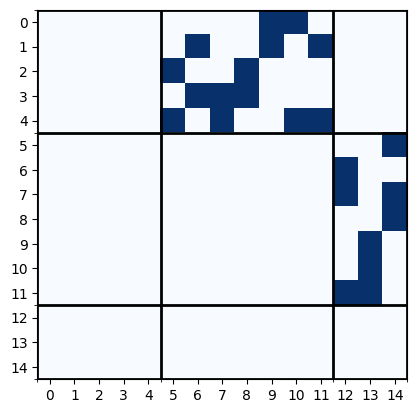

In [23]:
delta_matrix = np.zeros([16, 16], dtype=int)
delta_matrix[0, 1:6] = 1
delta_matrix[1:6, 6:13] = np.array([[1, 1, 0, 0, 0, 0, 0], 
                                    [1, 0, 1, 1, 0, 0, 0], 
                                    [0, 1, 1, 0, 1, 1, 0], 
                                    [0, 0, 0, 1, 1, 0, 1], 
                                    [0, 0, 0, 0, 0, 1, 1]])
delta_matrix[6:13, 13:16] = np.array([[1, 0, 0], 
                                      [1, 0, 0], 
                                      [1, 1, 0], 
                                      [0, 1, 0], 
                                      [0, 1, 1], 
                                      [0, 0, 1], 
                                      [0, 0, 1]])
reorder = np.array([ 0,  1,  2,  5,  4,  3, 11,  9, 10, 12,  6,  7,  8, 14, 13, 15])

ns = [1, 5, 7, 3]
delta_matrix = delta_matrix[reorder, :][:, reorder]

ns = ns[1:]
delta_matrix = delta_matrix[1:, 1:]

show_boundary_matrix(delta_matrix, ns, set_lim=False)

In [24]:
df_transpositions = collect_transpositions(delta_matrix, ns, path='data/complexes/example')


print(f'df_transpositions.shape = {df_transpositions.shape}')
df_transpositions.head()

df_transpositions.shape = (11, 14)


,cell0,cell1,hash_bt,hash_at,dp_bt,dp_at,transposition,transposition_type,switch_type,nested,x,y,a,b
1,1,2,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,J2sqbpnQ48LtFe20HsEAUkqy4GGMjhte7HBokhi0RQA,<src.depth.DepthPoset object at 0x705397d02f30>,<src.depth.DepthPoset object at 0x705397d03230>,"<1, 2>",birth-birth,switch forward,True,2,7,1,9
2,2,3,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,Hch7Jy3ORtkQDDERc_N9PsJoEKcHTDKxRs83iZYppNk,<src.depth.DepthPoset object at 0x705397d02f30>,<src.depth.DepthPoset object at 0x705397d02ea0>,"<2, 3>",birth-birth,no switch,True,3,6,2,7
3,3,4,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,vzPUoxuvbCxEsI5SVC188-HNcPhtehVc4RNPBHsZLKg,<src.depth.DepthPoset object at 0x705397d02f30>,<src.depth.DepthPoset object at 0x705397d03b00>,"<3, 4>",birth-birth,no switch,False,4,5,3,6
4,5,6,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,a-wU4c_wAXKQ4SDVk2X3oDdjR0vNgXsB9DeLWDqQebQ,<src.depth.DepthPoset object at 0x705397d02f30>,<src.depth.DepthPoset object at 0x705397d14e30>,"<5, 6>",death-death,no switch,False,4,5,3,6
5,6,7,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,YYo5rnpYI2eOPTklPKOLf137xSx0ZEB1-KorpXOpnXw,<src.depth.DepthPoset object at 0x705397d02f30>,<src.depth.DepthPoset object at 0x705397d15df0>,"<6, 7>",death-death,switch forward,True,3,6,2,7


In [25]:
df_transpositions_eqiations = check_equations(df_transpositions, with_preservation=False)

index_cols = ['transposition_type', 'switch_type', 'nested']
eq_cols = df_transpositions_eqiations.columns

df_transpositions_eqiations = pd.concat([df_transpositions, df_transpositions_eqiations], axis=1)


df_transpositions_eqiations.set_index(index_cols)[eq_cols].transpose().replace({True: '✔', False: '✘'}).fillna('')

transposition_type    birth-birth                 death-death                 \
switch_type        switch forward no switch         no switch switch forward   
nested                      True      True  False       False          True    
Eq08                            ✔                                              
Eq09                            ✔                                              
Eq10                            ✔                                              
Eq11                            ✔                                              
Eq12                            ✔                                              
Eq13                            ✔                                              
Eq14                            ✔                                              
Eq15                            ✔                                              
Eq16                                      ✔                                    
Eq17                                      ✔                                    
Eq28                                                                       ✔   
Eq29                                                                       ✔   
Eq30                                                                       ✔   
Eq31                                                                       ✔   
Eq32                                                                       ✔   
Eq33                                                                       ✔   
Eq34                                                                       ✔   
Eq35                                                                       ✔   
Eq48                                                                           
Eq49                                                                           
Eq50                                                                           
Eq51                                                                           
Eq52                                                                           
Eq53                                                                           
Eq54                                                                           
Eq55                                                                           

transposition_type    birth-death                          birth-birth  \
switch_type        switch forward no switch switch forward   no switch   
nested                      True      False          True        True    
Eq08                                                                     
Eq09                                                                     
Eq10                                                                     
Eq11                                                                     
Eq12                                                                     
Eq13                                                                     
Eq14                                                                     
Eq15                                                                     
Eq16                                                                 ✔   
Eq17                                                                 ✔   
Eq28                                                                     
Eq29                                                                     
Eq30                                                                     
Eq31                                                                     
Eq32                                                                     
Eq33                                                                     
Eq34                                                                     
Eq35                                                                     
Eq48                            ✔                        ✔               
Eq49                            ✔                  

In [26]:
df_transpositions_eqiations[(df_transpositions_eqiations[eq_cols] == False).any(axis=1)]

,cell0,cell1,hash_bt,hash_at,dp_bt,dp_at,transposition,transposition_type,switch_type,nested,...,Eq34,Eq35,Eq48,Eq49,Eq50,Eq51,Eq52,Eq53,Eq54,Eq55
6,7,8,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,kuDlPe5q2XxobjKumg_68wQFmw62Cfx14U5R1dCsnhs,<src.depth.DepthPoset object at 0x705397d02f30>,<src.depth.DepthPoset object at 0x705397d159d0>,"<7, 8>",birth-death,switch forward,True,...,None,None,True,True,False,True,True,True,True,False
8,9,10,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,w7DOlwOP_6pFRUNOIAyf25bguQInrau2zXy7gM1TQzI,<src.depth.DepthPoset object at 0x705397d02f30>,<src.depth.DepthPoset object at 0x705397d1d5b0>,"<9, 10>",birth-death,switch forward,True,...,None,None,True,True,False,True,True,True,True,True


In [29]:
row = df_transpositions_eqiations.loc[1]
row = df_transpositions_eqiations.loc[6]


display(Markdown(get_transposition_stats(**row, checked_equations=row[eq_cols])))

# Transposition <7, 8>
Here is a __birth-death__ __switch forward__ transposition <7, 8>.

| a | b | x | y |
| --- | --- | --- | --- |
| 2 | 7 | 8 | 14 |

## Birth Death Pairs
|                          |                                                                   |
|:-------------------------|:------------------------------------------------------------------|
| Before the transposition | $\{(8, 14), (2, 7), (10, 13), (11, 12), (4, 5), (3, 6), (1, 9)\}$ |
| After the transposition  | $\{(2, 8), (10, 13), (11, 12), (4, 5), (3, 6), (1, 9), (7, 14)\}$ |

## Relations
|                          | Algorithm 1                    | Algorithm 2                                            |
|:-------------------------|:-------------------------------|:-------------------------------------------------------|
| Before the transposition | $\{(6, 7), (12, 13), (5, 7)\}$ | $\{(3, 1), (1, 0), (2, 1), (4, 2)\}$                   |
| After the transposition  | $\{(6, 8), (12, 13)\}$         | $\{(11, 7), (2, 1), (3, 1), (10, 7), (4, 2), (1, 0)\}$ |

## Successors and Predecessers
|                 | $\text{Set}^\text{bt}(2, 7)$                         | $\text{Set}^\text{bt}(8, 14)$                | $\text{Set}^\text{at}(2, 8)$                 | $\text{Set}^\text{at}(7, 14)$                             |
|:----------------|:-----------------------------------------------------|:---------------------------------------------|:---------------------------------------------|:----------------------------------------------------------|
| $\text{Succ}_1$ | $\text{Succ}_1^\text{bt}(2, 7) = \emptyset$          | $\text{Succ}_1^\text{bt}(8, 14) = \emptyset$ | $\text{Succ}_1^\text{at}(2, 8) = \emptyset$  | $\text{Succ}_1^\text{at}(7, 14) = \emptyset$              |
| $\text{Pred}_1$ | $\text{Pred}_1^\text{bt}(2, 7) = \{(4, 5), (3, 6)\}$ | $\text{Pred}_1^\text{bt}(8, 14) = \emptyset$ | $\text{Pred}_1^\text{at}(2, 8) = \{(3, 6)\}$ | $\text{Pred}_1^\text{at}(7, 14) = \emptyset$              |
| $\text{Succ}_2$ | $\text{Succ}_2^\text{bt}(2, 7) = \{(1, 9)\}$         | $\text{Succ}_2^\text{bt}(8, 14) = \emptyset$ | $\text{Succ}_2^\text{at}(2, 8) = \{(1, 9)\}$ | $\text{Succ}_2^\text{at}(7, 14) = \emptyset$              |
| $\text{Pred}_2$ | $\text{Pred}_2^\text{bt}(2, 7) = \{(4, 5)\}$         | $\text{Pred}_2^\text{bt}(8, 14) = \emptyset$ | $\text{Pred}_2^\text{at}(2, 8) = \{(4, 5)\}$ | $\text{Pred}_2^\text{at}(7, 14) = \{(11, 12), (10, 13)\}$ |

## Temp Sets
| Before the Transposition   | After the Transposition   |
|----------------------------|---------------------------|

## Equations
There are 2 equations are wrong:
| eq   | left (formula)                  | left (paramatrized)              | left (value)             | right (formula)                          | right (paramatrized)                     | right (value)   | correct   |
|:-----|:--------------------------------|:---------------------------------|:-------------------------|:-----------------------------------------|:-----------------------------------------|:----------------|:----------|
| Eq50 | $\text{Pred}_1^\text{at}(a, x)$ | $\text{Pred}_1^\text{at}(2, 8)$  | $\{(3, 6)\}$             | $\{(t, x):\; U_1^\text{bt}[t, x] = 1\}$  | $\{(t, 8):\; U_1^\text{bt}[t, 8] = 1\}$  | $\emptyset$     | False     |
| Eq55 | $\text{Pred}_2^\text{at}(b, y)$ | $\text{Pred}_2^\text{at}(7, 14)$ | $\{(11, 12), (10, 13)\}$ | $\{(b, s) :\; U_2^\text{bt}[b, s] = 1\}$ | $\{(7, s) :\; U_2^\text{bt}[7, s] = 1\}$ | $\emptyset$     | False     |